#  Hotel Booking Analysis – Exploratory Data Analysis (EDA)

### Project Details

**Project Title:** Hotel Booking Analysis – Exploratory Data Analysis  
**Project Type:** Exploratory Data Analysis (EDA)  
**Contribution:** Individual  
**Email ID:** anushreekashyap03@gmail.com  


### Project Summary

This project was assigned with the objective of understanding the business
performance of a hotel group. The dataset contains booking information for
two types of hotels: City Hotel and Resort Hotel.

The data spans three years (2015, 2016, and 2017) and includes details related
to bookings, revenue, stay duration, booking cancellations, number of guests
(adults, children, and babies), waiting period, repeat customers, meal
preferences, and booking channels.

The dataset also provides information about the countries from which bookings
were made and includes travel agents and company-based bookings that contribute
to hotel business.

Since the data is divided between City Hotel and Resort Hotel, it allows a
fair comparison between both hotel types. Before performing any visualization
or analysis, data cleaning and data wrangling were carried out to handle
missing values, duplicates, and inconsistencies.

The analysis was performed both individually for City and Resort hotels and
comparatively to derive meaningful business insights. Various visualizations
were used to support better understanding and interpretation of the data.


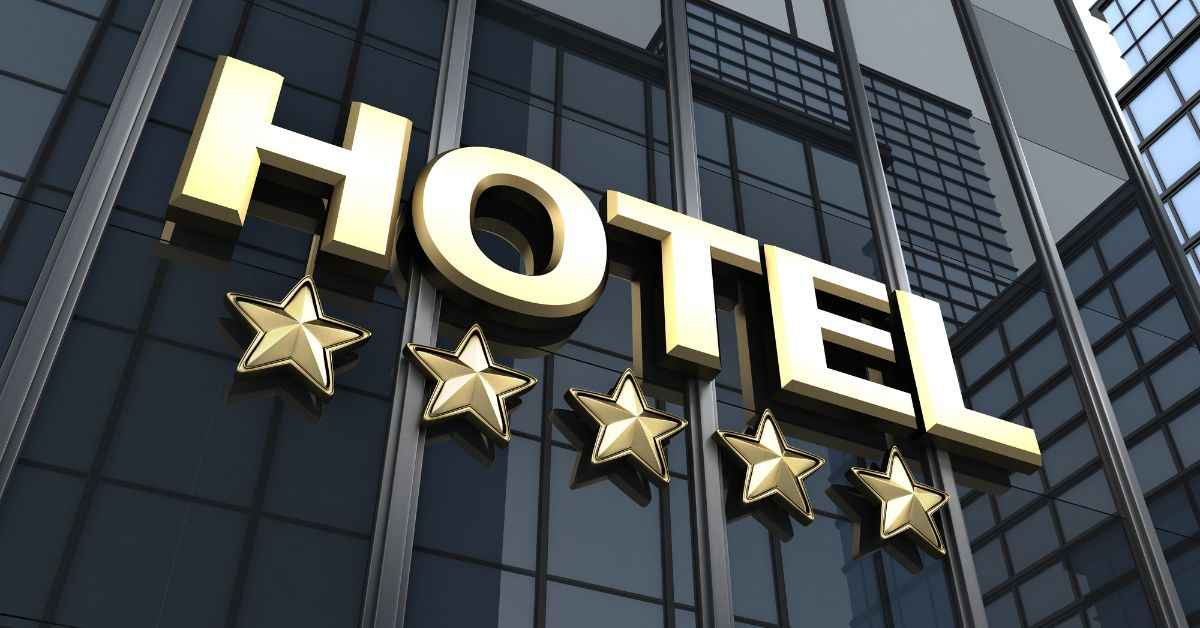

### GitHub Link

https://github.com/github-anushree/Hotel_booking_analysis_EDA


## Overall Project Flow

**1. Understand Business Problem & Dataset** 

**2. Load Data & First Look** 

**3. Data Quality Checks (Missing, Duplicates, Types)** 

**4. Feature Understanding & Data Cleaning** 

**5. Univariate Analysis**

**6. Bivariate Analysis**

**7. Multivariate Analysis** 

**8. Time-based & Trend Analysis** 

**9. Business Questions & Insights**

**10. Final Insights, Recommendations & Interview Story**


### Step 1: loading Strategy (without loading full data)

In [2]:
import pandas as pd

file_path = "arbor_Hotel_Booking_EDA.xlsx"
xls = pd.ExcelFile(file_path)

xls.sheet_names

['Sheet1']

**Load ONLY first sheet + sample rows**

In [3]:
df = pd.read_excel(file_path, sheet_name=0, nrows=5000)

**First Look Commands**

In [19]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
df.shape

(5000, 32)

When the dataset is large, We first load a sample of rows to understand structure, columns, and data types. Once We are confident, We load the full dataset.

In [21]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### Variables Description

- **hotel** – Type of hotel (City Hotel or Resort Hotel)
- **is_canceled** – Whether the booking was canceled (1) or not (0)
- **lead_time** – Number of days between booking date and arrival date
- **arrival_date_year** – Year of arrival
- **arrival_date_month** – Month of arrival
- **arrival_date_week_number** – Week number of the year for arrival
- **stays_in_weekend_nights** – Number of weekend nights stayed
- **stays_in_week_nights** – Number of weekday nights stayed
- **adults** – Number of adults
- **children** – Number of children
- **babies** – Number of babies
- **meal** – Type of meal booked
- **country** – Country of the guest
- **market_segment** – Booking market segment
- **distribution_channel** – Booking distribution channel
- **is_repeated_guest** – Whether the guest is a repeat customer (1 or 0)
- **previous_cancellations** – Number of previous canceled bookings
- **previous_bookings_not_canceled** – Number of previous non-canceled bookings
- **reserved_room_type** – Code of room type reserved
- **assigned_room_type** – Code of room type assigned
- **booking_changes** – Number of changes made to the booking
- **deposit_type** – Type of deposit made
- **agent** – ID of the travel agent
- **company** – ID of the company
- **days_in_waiting_list** – Number of days booking was on waiting list
- **customer_type** – Type of customer
- **adr** – Average Daily Rate (total lodging revenue / number of nights)
- **required_car_parking_spaces** – Number of parking spaces required
- **total_of_special_requests** – Number of special requests made
- **reservation_status** – Final reservation status
- **reservation_status_date** – Date when reservation status was last updated


In [23]:
df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   int64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           5000 non-null   object        
 1   is_canceled                     5000 non-null   int64         
 2   lead_time                       5000 non-null   int64         
 3   arrival_date_year               5000 non-null   int64         
 4   arrival_date_month              5000 non-null   object        
 5   arrival_date_week_number        5000 non-null   int64         
 6   arrival_date_day_of_month       5000 non-null   int64         
 7   stays_in_weekend_nights         5000 non-null   int64         
 8   stays_in_week_nights            5000 non-null   int64         
 9   adults                          5000 non-null   int64         
 10  children                        5000 non-null   int64         
 11  babi

### STEP 2 — Understanding Partial Load vs Full Load

In [4]:
df = pd.read_excel(file_path, sheet_name = "Sheet1")

In [7]:
df.shape

(119390, 32)

#### Final Checklist

### STEP 3 — Data Quality Checks

**Dataset Overview (Re-confirm)**

In [12]:
df.shape

(119390, 32)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

**Key Points**

We first reconfirm dataset size and data types to understand how much cleaning is needed.

Children is float64(NaN) due to missing values; I handle it after deciding missing value strategy.

Agent is float64(NaN), we do not convert it blindly, if needed later, we convert it into string or category.

arrival_date_month → object (This is expected, we will later, order months properly and convert to categorical with order. Cuurently this is not a data quality issue.)

adr → float64(correct data type but later we check is adr = 0? or adr < 0)

We validated data types and kept them unchanged since they correctly represent the data semantics. Any conversions were planned after missing value treatment.

**Missing Values Check**

In [9]:
#Column-wise missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

| Column   | Missing | % Approx   | Meaning         |
| -------- | ------- | ---------- | --------------- |
| children | 4       | negligible | Easy fix        |
| country  | ~488    | small      | Needs handling  |
| agent    | ~16k    | large      | Meaningful      |
| company  | ~112k   | very large | Business-driven |

Data types are correct, but missing values drive future decisions

**Missing values percentage**

In [10]:
(df.isna().sum()/len(df))*100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

What We Are Looking For:

Columns with 0% missing → safe

Columns with low missing (<5%) → easy to handle

Columns with high missing (>30%) → business discussion needed

We don’t blindly drop missing values. We check their percentage and business importance first.

**Duplicate Records Check**

In [11]:
df.duplicated().sum()

31994

In [12]:
# 31994 Duplicates Found:
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


Duplicate bookings can distort revenue and demand analysis, so we always check this

**We found duplicate rows, but We did not drop them immediately because in booking data, multiple customers can share identical booking attributes. We first evaluate whether duplicates represent real bookings or data errors.**

Correct decision is: we will keep duplicate values, because duplicate can represents multiple real booking and these are transectional record not master data.

**Data Type Validation**

In [13]:
df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

**Unique value check (Categorical columns)**

In [14]:
df.nunique().sort_values()


hotel                                2
is_canceled                          2
is_repeated_guest                    2
arrival_date_year                    3
deposit_type                         3
reservation_status                   3
customer_type                        4
required_car_parking_spaces          5
meal                                 5
babies                               5
distribution_channel                 5
children                             5
total_of_special_requests            6
market_segment                       8
reserved_room_type                  10
arrival_date_month                  12
assigned_room_type                  12
adults                              14
previous_cancellations              15
stays_in_weekend_nights             17
booking_changes                     21
arrival_date_day_of_month           31
stays_in_week_nights                35
arrival_date_week_number            53
previous_bookings_not_canceled      73
days_in_waiting_list     

Columns with 1 unique value → useless

Columns with very high unique values → IDs, not categories

We performed data quality checks including missing values, duplicates, data types, and sanity checks to ensure the dataset was reliable before analysis.

High-cardinality columns like agent and company are treated as identifiers, not features

**Feature Classification**

| Type        | Columns                                 |
| ----------- | --------------------------------------- |
| Binary      | hotel, is_canceled, is_repeated_guest   |
| Categorical | meal, customer_type, market_segment     |
| Date/Time   | arrival_date_*, reservation_status_date |
| Numerical   | lead_time, adr, stays_*                 |
| Identifiers | agent, company, country                 |


**We performed duplicate checks and cardinality analysis. Although duplicate rows exist, they represent valid transactional bookings. The dataset has a healthy mix of categorical, numerical, and time-based features with no structural issues.**

### What Did You Know About the Dataset?

1. The dataset is related to Hotel Bookings and is used to analyze and explore
   important factors that affect hotel booking behavior.

2. The dataset contains **119,390 rows** and **32 columns**.

3. There are **31,994 duplicate records**, which represent valid transactional
   bookings and were not removed blindly.

4. There are **4 columns with missing values**:
   - `company`
   - `agent`
   - `country`
   - `children`

5. The dataset includes separate columns for `adults`, `children`, and `babies`
   to represent the total number of guests. These columns were later combined
   into a single feature called **total number of guests** for better analysis.


### STEP 4 — Data Cleaning & Feature Understanding

#### PART A — Feature Understanding (Before Cleaning)

**1. Hotel & Booking Status**

| Column                    | Meaning                                |
| ------------------------- | -------------------------------------- |
| `hotel`                   | Type of hotel (City / Resort)          |
| `is_canceled`             | 1 = booking canceled, 0 = not canceled |
| `reservation_status`      | Final booking outcome                  |
| `reservation_status_date` | Date when status was updated           |


These columns help analyze cancellation behavior and booking outcomes

**2. Arrival & Time-Based Columns**

| Column                      | Meaning         |
| --------------------------- | --------------- |
| `arrival_date_year`         | Year of arrival |
| `arrival_date_month`        | Month name      |
| `arrival_date_week_number`  | Week of year    |
| `arrival_date_day_of_month` | Day number      |


These are used for:

•	Seasonality
•	Monthly trends
•	Demand analysis


**3. Stay Duration**

| Column                    | Meaning        |
| ------------------------- | -------------- |
| `stays_in_weekend_nights` | Sat–Sun nights |
| `stays_in_week_nights`    | Mon–Fri nights |


We’ll later create:

total_stay_nights (very powerful feature)

**4. Guest Information**

| Column              | Meaning                   |
| ------------------- | ------------------------- |
| `adults`            | Number of adults          |
| `children`          | Number of children        |
| `babies`            | Number of babies          |
| `customer_type`     | Transient / Contract etc. |
| `is_repeated_guest` | Returning customer flag   |


These columns help analyze:

•	Guest composition
•	Loyalty behavior


**5. Pricing & Revenue**

| Column         | Meaning                        |
| -------------- | ------------------------------ |
| `adr`          | Average Daily Rate             |
| `deposit_type` | Deposit policy                 |
| `lead_time`    | Days between booking & arrival |


These are business-critical columns.

**6. Booking Source & Channel**

| Column                 | Meaning               |
| ---------------------- | --------------------- |
| `market_segment`       | Corporate / Online TA |
| `distribution_channel` | Booking channel       |
| `agent`                | Travel agent ID       |
| `company`              | Company ID            |
| `country`              | Guest country         |


#### PART B — Data Cleaning

**1. Handling Missing Values**

In [19]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [20]:
#children (4 missing values)
#Missing → assume 0 children
df['children'] = df['children'].fillna(0)

In [21]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [24]:
df['children']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
119385    0.0
119386    0.0
119387    0.0
119388    0.0
119389    0.0
Name: children, Length: 119390, dtype: float64

In [25]:
#country (~488 missing)
df['country'] = df['country'].fillna('Unknown')

We replaced missing country values with ‘Unknown’ to preserve booking records

agent & company (High missing)

Business meaning:

Missing agent → direct booking

Missing company → not a corporate booking

In [26]:
df['agent'] = df['agent'].fillna(0)

In [27]:
df['company'] = df['company'].fillna(0)

In [28]:
df['agent']

0           0.0
1           0.0
2           0.0
3         304.0
4         240.0
          ...  
119385    394.0
119386      9.0
119387      9.0
119388     89.0
119389      9.0
Name: agent, Length: 119390, dtype: float64

In [29]:
df['company']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
119385    0.0
119386    0.0
119387    0.0
119388    0.0
119389    0.0
Name: company, Length: 119390, dtype: float64

**2. Data Type Optimization**

In [30]:
df['children'] = df['children'].astype(int)

In [31]:
df['children'].dtype

dtype('int32')

In [32]:
df['agent'] = df['agent'].astype(int)

In [33]:
df['agent'].dtype

dtype('int32')

In [34]:
df['company'].dtype

dtype('float64')

In [35]:
df['company'] = df['company'].astype(int)

After handling missing values, I corrected data types to match business meaning

**3. Feature Engineering**

In [27]:
#Total Stay Nights
df['total_stay_nights'] = (
    df['stays_in_weekend_nights'] + df['stays_in_week_nights']
)

df['total_stay_nights'] will be Used in pricing & revenue insights

**4. Total Guests**

In [37]:
df['total_guest'] =  df['adults'] + df['children'] + df['babies']

In [38]:
df['total_guest']

0         2
1         2
2         1
3         1
4         2
         ..
119385    2
119386    3
119387    2
119388    2
119389    2
Name: total_guest, Length: 119390, dtype: int64

We understood the business meaning of each feature, handled missing values logically instead of blindly, optimized data types, and engineered new features to improve analysis

In [ ]:
#save it for now
df.to_excel("hotel_booking_cleaned_step4.xlsx", index=False)

### Data Wrangling

- Handled missing values in `children`, `country`, `agent`, and `company`
  using business logic instead of blindly dropping records.
- Converted data types where necessary after handling missing values.
- Created new features such as:
  - **total_stay_nights**
  - **total_guests**
- Ensured data consistency and readiness for analysis.


### STEP 5 — Univariate Analysis

(Understanding ONE variable at a time)

Objective of Step 5

How does each important variable behave on its own?

**Target Variable Analysis: is_canceled**

Cancellation directly impacts revenue

In [6]:
#Value counts
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [8]:
#Percentage distribution
df['is_canceled'].value_counts(normalize = True)*100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

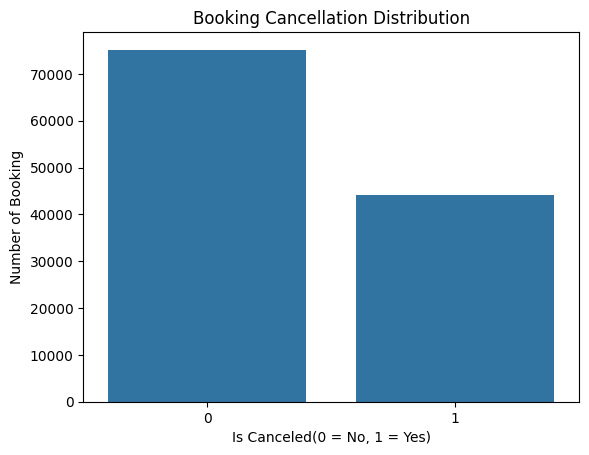

In [11]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x= "is_canceled", data= df)
plt.title('Booking Cancellation Distribution')
plt.xlabel('Is Canceled(0 = No, 1 = Yes)')
plt.ylabel('Number of Booking')
plt.show()

#### 1️ Booking Cancellation Distribution (`is_canceled`)

**Business Interpretation**
- A significant portion of hotel bookings are canceled, which poses a **direct risk to revenue**.
- High cancellation rates can result in **poor room utilization**, last-minute vacancies, and operational inefficiencies.
- This pattern suggests the need for **improved cancellation policies**, **dynamic pricing strategies**, or **better customer segmentation** to reduce cancellations.

**Technical Interpretation**
- The target variable `is_canceled` shows **class imbalance**, with **non-canceled bookings occurring more frequently** than canceled ones.
- Such imbalance should be carefully handled during **model building** (e.g., using class weights or resampling techniques).
- This confirms that `is_canceled` is a **key target variable** and should be prioritized for deeper exploratory and predictive analysis.


A significant portion of bookings are canceled, which indicates a potential revenue leakage problem

**Hotel Type Analysis: hotel**

In [12]:
df['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

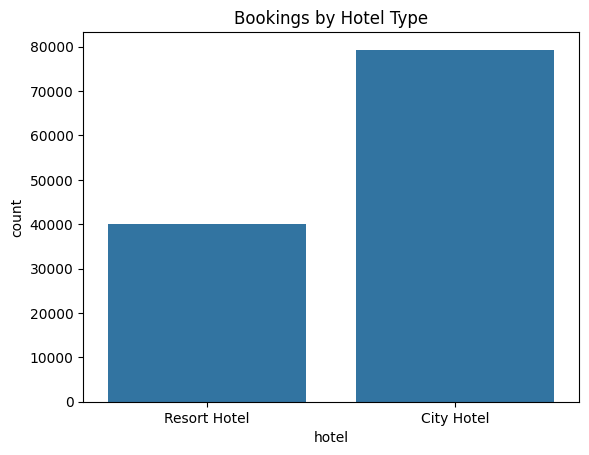

In [53]:
sns.countplot(x = 'hotel', data = df)
plt.title('Bookings by Hotel Type')
plt.show()

City hotels generally receive more bookings compared to resort hotels.

#### 2️ Bookings by Hotel Type (`hotel`)

**Business Interpretation**
- **City Hotels** receive a significantly higher number of bookings compared to **Resort Hotels**.
- This indicates **stronger demand in urban or business-centric locations**, likely driven by work-related travel and shorter stays.
- Since booking volume is higher for City Hotels, they may also experience **higher absolute cancellation counts**, which should be analyzed separately using cancellation rates.

**Technical Interpretation**
- The `hotel` column has **low cardinality** with only **two categories**, making it well-suited for **group-by and comparative analysis**.
- This feature is useful for comparing key metrics such as **cancellation rate**, **Average Daily Rate (ADR)**, **lead time**, and **special requests** across hotel types.


**Reservation Status**

In [14]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

Why this matters:

•	Confirms final booking outcomes

•	Helps validate is_canceled


**Customer Type**

In [15]:
df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

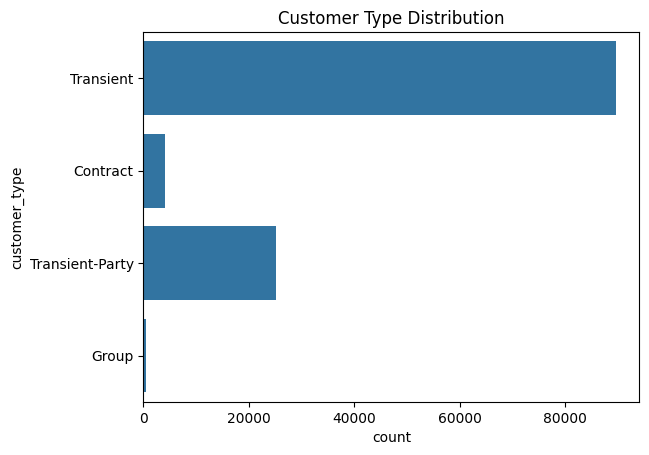

In [16]:
sns.countplot(y = 'customer_type', data = df)
plt.title('Customer Type Distribution')
plt.show()

Insight:

•	Transient customers usually dominate

•	Useful later for cancellation risk


#### 3️ Customer Type Distribution (`customer_type`)

**Business Interpretation**
- **Transient customers** make up the majority of bookings, showing that most guests are **short-term or individual travelers**.
- **Contract** and **Group** customers represent a **very small share** of total bookings.
- Hotels can potentially improve long-term revenue by introducing **loyalty programs** or targeted offers to convert transient guests into **repeat or contract customers**.

**Technical Interpretation**
- The distribution of `customer_type` is **highly skewed**, with the **Transient** category dominating the dataset.
- This variable is likely to have a **strong relationship with cancellation behavior**, booking lead time, and pricing patterns.
- It is well-suited for **categorical comparisons** against the target variable `is_canceled` in further analysis.


**Market Segment**

In [17]:
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

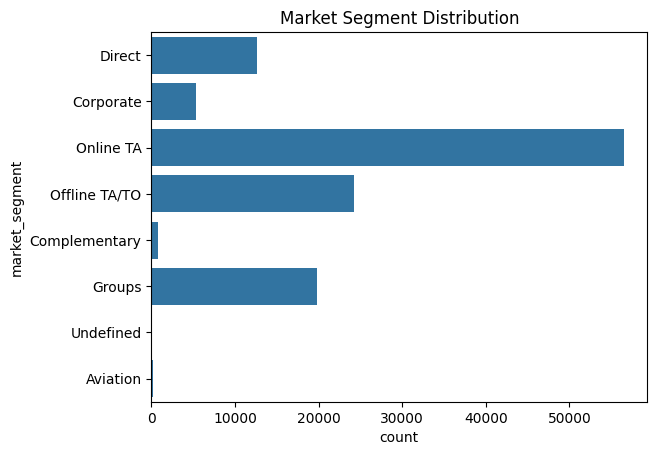

In [18]:
sns.countplot(y = 'market_segment', data = df)
plt.title('Market Segment Distribution')
plt.show()

Online travel agents contribute the highest number of bookings

#### 4. Market Segment Distribution (`market_segment`)

**Business Interpretation**
- **Online Travel Agents (OTAs)** generate the **highest number of bookings**, making them the most dominant booking channel.
- Heavy dependence on OTAs can lead to **higher commission costs** and often comes with an **increased risk of cancellations**.
- This presents an opportunity for hotels to **boost direct bookings** through their own websites, loyalty programs, or exclusive offers to improve **profit margins**.

**Technical Interpretation**
- The `market_segment` feature has **multiple categories** but remains **manageable in cardinality**, making it suitable for analysis.
- It is ideal for **Top-N category analysis** and for comparing metrics such as **cancellation rates**, **Average Daily Rate (ADR)**, and **lead time**.
- The count distribution clearly confirms the **dominance of OTA-related segments** in the dataset.


**Distribution Channel**

In [19]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

This helps understand:

•	Where bookings come from

•	Dependency on OTAs


**Lead Time**

In [20]:
#Statistical summary
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

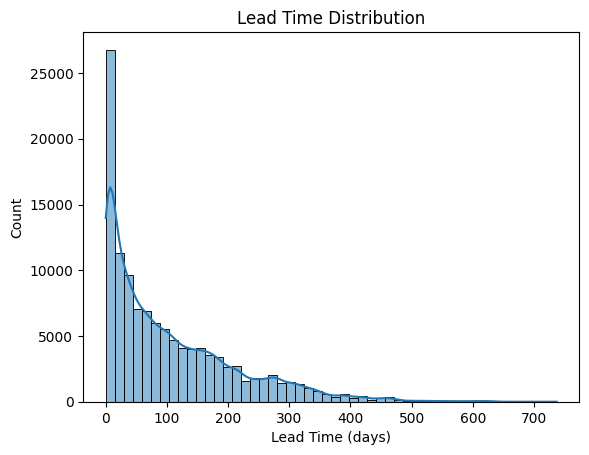

In [21]:
sns.histplot(df['lead_time'], bins = 50, kde= True)
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.show()

Key Insight:

•	Most bookings are made close to arrival

•	Long lead times may indicate higher cancellation risk


#### 5. Lead Time Distribution (`lead_time`)

**Business Interpretation**
- The majority of bookings are made **close to the arrival date**, indicating a preference for **last-minute or short-term planning** among guests.
- A **long tail** in the distribution shows that some customers book **several months in advance**.
- Bookings with **longer lead times** may have a **higher likelihood of cancellation**, which should be explored further to improve forecasting and policy decisions.

**Technical Interpretation**
- The `lead_time` distribution is **right-skewed** and does **not follow a normal distribution**.
- The presence of **extreme values** suggests possible **outliers** or exceptional booking behavior.
- Due to skewness, the **mean is not a reliable measure** of typical lead time; the **median provides a more accurate representation** of central tendency.


**ADR (Average Daily Rate)**

In [23]:
#Summary
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

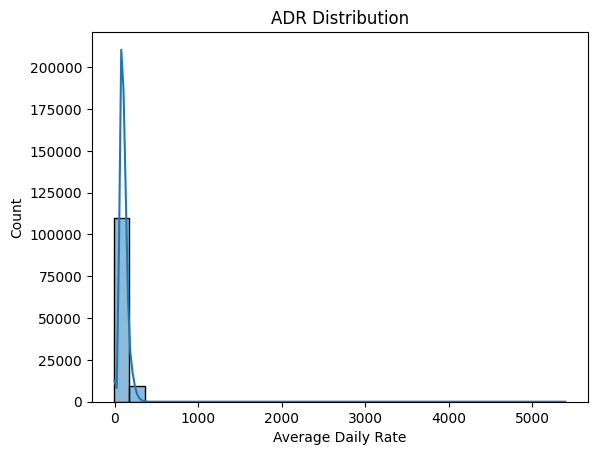

In [24]:
#Distribution
sns.histplot(df['adr'], bins = 30, kde = True)
plt.title('ADR Distribution')
plt.xlabel('Average Daily Rate')
plt.show()

Insights to Look For:

•	Right-skewed distribution

•	Presence of outliers

•	Possible zero or negative values (to be discussed later)


ADR shows a right-skewed distribution with some extreme values

#### 6. ADR – Average Daily Rate Distribution (`adr`)

**Business Interpretation**
- Most hotel bookings fall within a **reasonable and expected price range**, indicating standard pricing behavior for the majority of guests.
- A small number of bookings show **extremely high ADR values**, which may correspond to **premium room types**, **special events**, **seasonal spikes**, or possible **pricing anomalies**.
- An effective pricing strategy should aim to **balance affordability with revenue maximization**, while closely monitoring unusually high rates.

**Technical Interpretation**
- The `adr` variable exhibits a **strong right-skewed distribution**.
- The presence of **outliers** implies that:
  - The **mean ADR can be misleading**, as it is influenced by extreme values.
  - The **median ADR** provides a more accurate measure of typical pricing behavior.
- For advanced analysis or modeling, **outlier treatment techniques** such as **capping, transformation, or removal** may be required.


**Total Stay Nights**

In [28]:
df['total_stay_nights'].describe()

count    119390.000000
mean          3.427900
std           2.557439
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_stay_nights, dtype: float64

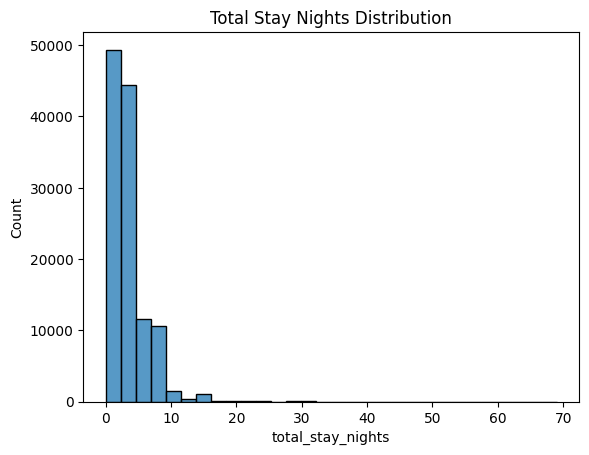

In [29]:
sns.histplot(df['total_stay_nights'], bins=30)
plt.title('Total Stay Nights Distribution')
plt.show()


Insight:

•	Most guests stay for short durations

•	Long stays are rare


#### 7. Total Stay Nights Distribution (`total_stay_nights`)

**Business Interpretation**
- The majority of guests stay for **short durations**, typically **1 to 3 nights**.
- **Long-stay bookings are relatively rare**, indicating limited demand for extended stays.
- This suggests that hotels mainly cater to **short-term travelers**, such as business visitors or short leisure trips, rather than long-term accommodations.

**Technical Interpretation**
- The `total_stay_nights` distribution is **right-skewed**, with a **high concentration of values at the lower end**.
- This confirms that `total_stay_nights` is a **meaningful engineered feature**, effectively capturing stay duration behavior.
- The feature can be leveraged to analyze **revenue contribution**, **customer segmentation**, and **cancellation patterns** in further analysis.


Overall, univariate analysis reveals that hotel bookings are dominated by transient customers,
city hotels, and online travel agents. Key numerical variables such as lead time, ADR, and stay
duration show right-skewed distributions with the presence of outliers, indicating the need for
careful interpretation using median-based metrics.


**We performed univariate analysis to understand the distribution and behavior of key categorical and numerical variables such as cancellations, hotel type, lead time, ADR, and stay duration**


### STEP 6 – Bivariate Analysis

Target Variable: is_canceled

-- Most bivariate analysis will answer:

“How does this variable affect cancellation?”

#### 1. Cancellation Rate by Hotel Type

In [35]:
hotel_cancel = (
df.groupby('hotel')['is_canceled'].mean().sort_values(ascending = False)
)

hotel_cancel

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

<Axes: title={'center': 'Cancellation Rate by Hotel Type'}, xlabel='hotel'>

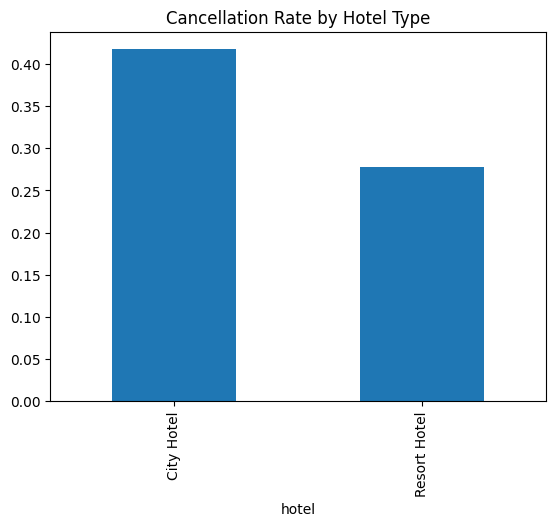

In [36]:
hotel_cancel.plot(kind = 'bar', title = 'Cancellation Rate by Hotel Type')

**1.  Business Interpretation**
- One hotel type exhibits a **higher cancellation rate** compared to the other.
- This suggests **differences in customer behavior** between hotel types, such as purpose of travel or booking flexibility.
- Hotel management should consider applying **different cancellation policies, pricing strategies, or overbooking rules** for each hotel type.

**Technical Interpretation**
- The analysis was performed using **`groupby()` combined with `mean()`** on the binary column `is_canceled`.
- Since `is_canceled` is binary (0 = not canceled, 1 = canceled), its **mean directly represents the cancellation probability**.
- This is a **standard, statistically valid approach** for comparing cancellation rates across categories.


#### 2. Cancellation vs Lead Time

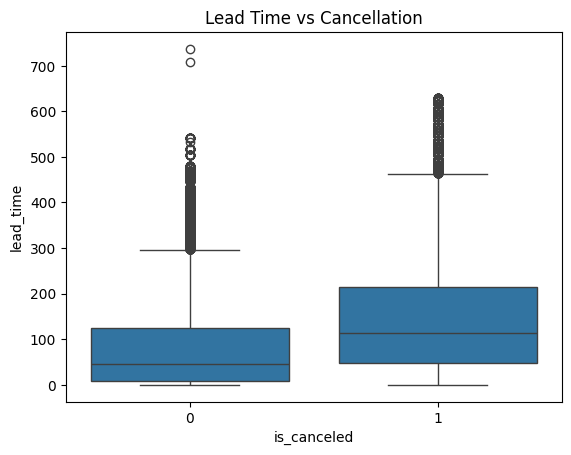

In [37]:
sns.boxplot(x = 'is_canceled', y = 'lead_time', data = df)
plt.title('Lead Time vs Cancellation')
plt.show()

This chart is a boxplot comparing Lead Time for:

is_canceled = 0 → Booking NOT canceled

is_canceled = 1 → Booking CANCELED

#### Lead Time vs Cancellation – Business Interpretation

The chart shows that canceled bookings generally have a much higher lead time
compared to non-canceled bookings. Customers who book far in advance are more
likely to cancel, as their plans are less certain. In contrast, bookings made
closer to the arrival date show lower cancellation behavior.

This insight suggests that hotels can reduce cancellations by applying stricter
policies, advance payments, or confirmation reminders for long lead-time bookings.


#### Lead Time vs Cancellation – Technical Interpretation

A boxplot comparison reveals a clear shift in the distribution of lead time
between canceled and non-canceled bookings. The median lead time for canceled
bookings is significantly higher, and the interquartile range is wider, indicating
greater variability. Outliers are present in both groups, but are more prominent
for canceled bookings, confirming a right-skewed distribution.


### 3 Cancellation vs ADR (Price Sensitivity)

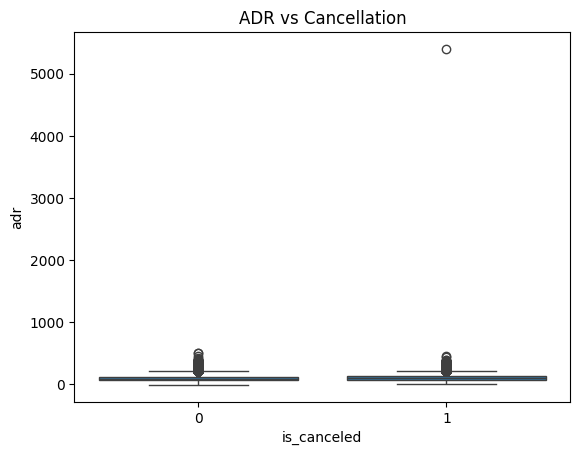

In [38]:
sns.boxplot(x = 'is_canceled',y = 'adr' , data = df)
plt.title('ADR vs Cancellation')
plt.show()

This boxplot compares Average Daily Rate (ADR) for:

is_canceled = 0 → Booking NOT canceled

is_canceled = 1 → Booking CANCELED

The goal is to see whether price (ADR) influences cancellation behavior

#### ADR vs Cancellation – Business Interpretation

The chart shows that the median ADR for canceled and non-canceled bookings is
very similar, indicating that room price alone does not significantly influence
cancellation behavior. Cancellations occur across all price ranges, suggesting
that factors such as booking lead time, customer type, and booking channel play
a more important role than pricing.


#### ADR vs Cancellation – Technical Interpretation

The boxplot comparison shows overlapping distributions of ADR for canceled and
non-canceled bookings. Both groups exhibit right-skewed distributions with
several high-value outliers. Since the medians and interquartile ranges are
similar, ADR alone does not show a strong direct relationship with cancellation.


#### 4 Cancellation by Customer Type

In [39]:
customer_cancel = (
    df.groupby('customer_type')['is_canceled']
      .mean()
      .sort_values(ascending=False)
)

customer_cancel


customer_type
Transient          0.407463
Contract           0.309617
Transient-Party    0.254299
Group              0.102253
Name: is_canceled, dtype: float64

<Axes: title={'center': 'Cancellation Rate by Customer Type'}, ylabel='customer_type'>

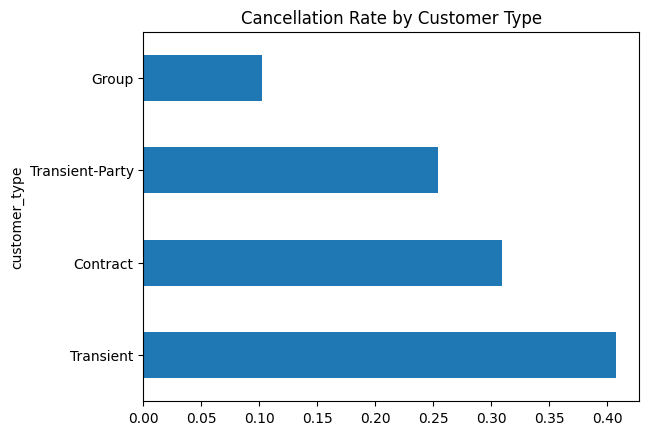

In [40]:
customer_cancel.plot(kind='barh', title='Cancellation Rate by Customer Type')


#### Business Interpretation
- Certain customer types, such as **Transient-Party**, show **higher cancellation rates**.
- **Contract** and **Group** customers tend to be **more reliable**, with lower likelihood of cancellation.
- Hotels should focus on **securing long-term contracts and group bookings** to reduce revenue uncertainty and improve occupancy stability.

#### Technical Interpretation
- This analysis involves a **categorical feature compared against a binary target variable** (`is_canceled`).
- Cancellation rates are calculated by aggregating the binary variable across customer types.
- The results help in **customer risk segmentation**, enabling targeted strategies for high- and low-risk customer groups.


### 5 Market Segment vs Cancellation

In [41]:
segment_cancel = (
    df.groupby('market_segment')['is_canceled']
      .mean()
      .sort_values(ascending=False)
)

segment_cancel


market_segment
Undefined        1.000000
Groups           0.610620
Online TA        0.367211
Offline TA/TO    0.343160
Aviation         0.219409
Corporate        0.187347
Direct           0.153419
Complementary    0.130552
Name: is_canceled, dtype: float64

<Axes: title={'center': 'Cancellation Rate by Market Segment'}, ylabel='market_segment'>

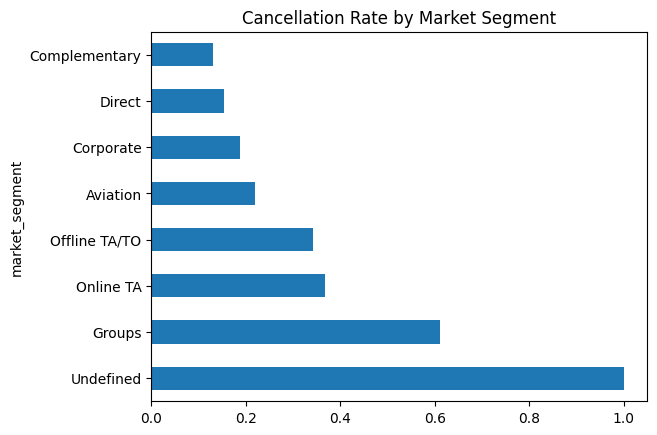

In [42]:
segment_cancel.plot(kind='barh', title='Cancellation Rate by Market Segment')


#### Business Interpretation
- **Online Travel Agent (OTA)** segments exhibit **higher cancellation rates** compared to other booking channels.
- **Direct** and **Corporate** bookings are generally **more stable and reliable**.
- Reducing dependency on OTAs and encouraging **direct or corporate bookings** can help improve booking reliability and reduce revenue volatility.

#### Technical Interpretation
- This is a **categorical vs binary variable analysis**, comparing `market_segment` with the target variable `is_canceled`.
- The `market_segment` feature has **higher cardinality**, making it suitable for **Top-N segment analysis**.
- Identifies booking channels with **higher cancellation risk**, useful for segmentation and strategic decision-making.


### 6 Cancellation vs Total Stay Nights

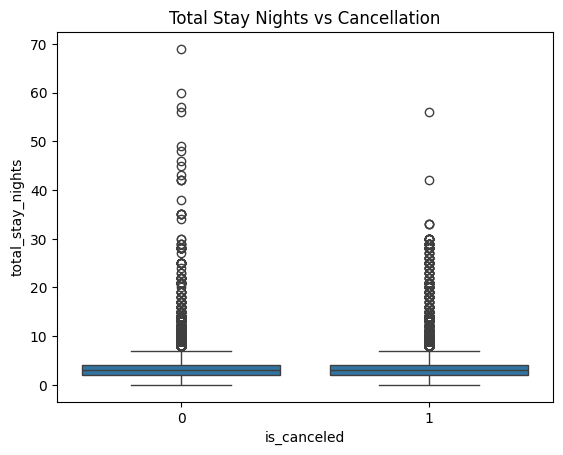

In [43]:
sns.boxplot(x='is_canceled', y='total_stay_nights', data=df)
plt.title('Total Stay Nights vs Cancellation')
plt.show()


This chart compares total stay duration for:

is_canceled = 0 → Booking NOT canceled

is_canceled = 1 → Booking CANCELED

The goal is to understand:

Does how long a guest plans to stay affect cancellation?

#### Total Stay Nights vs Cancellation – Business Interpretation

The chart shows that most bookings are for short stays of 2–3 nights.
However, non-canceled bookings tend to include more long-stay cases,
while canceled bookings are mostly concentrated around shorter stays.
This suggests that guests planning longer stays are more committed and
less likely to cancel their bookings.


#### Total Stay Nights vs Cancellation – Technical Interpretation

The boxplot shows similar median values and interquartile ranges for both
canceled and non-canceled bookings, indicating comparable typical stay
durations. However, non-canceled bookings have more extreme long-stay
outliers, suggesting that longer stays are associated with lower
cancellation probability.


**We performed bivariate analysis to understand how cancellation behavior is influenced by lead time, hotel type, pricing, customer type, and booking channels. We identified long lead times and online travel agents as key risk factors**

### STEP 7 – Time & Seasonality Analysis

Objective of Step 7

To understand:

How bookings and cancellations change over time

Which months/seasons are risky or profitable

Demand patterns across the year:

**“Do cancellations or prices change seasonally?”**

#### 1. Bookings by Month (Seasonality)

In [44]:
monthly_bookings = (
    df.groupby('arrival_date_month')
      .size()
      .reindex([
          'January','February','March','April','May','June',
          'July','August','September','October','November','December'
      ])
)
monthly_bookings

arrival_date_month
January       5929
February      8068
March         9794
April        11089
May          11791
June         10939
July         12661
August       13877
September    10508
October      11160
November      6794
December      6780
dtype: int64

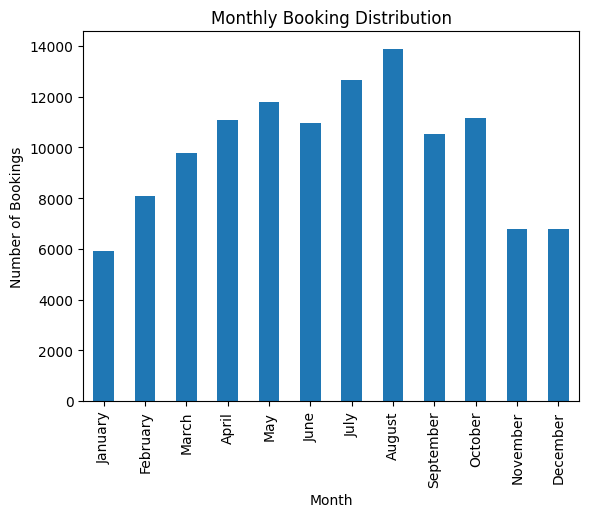

In [45]:
monthly_bookings.plot(kind='bar', title='Monthly Booking Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.show()

#### Business Interpretation
- Hotel bookings are **not evenly distributed across months**, indicating clear **seasonal patterns**.
- Certain months, typically **summer or peak travel periods**, experience **significantly higher demand**.
- Hotels can maximize revenue by **increasing prices**, optimizing **inventory**, and planning **staffing levels** during high-demand months.

#### Technical Interpretation
- The data was **grouped by arrival month** to analyze booking volume across the year and identify seasonality.
- Month ordering was **explicitly defined** to ensure **chronological sequencing**, avoiding incorrect alphabetical ordering.
- This approach enables accurate **time-based comparison and trend analysis**.


### 2. Monthly Cancellation Rate

In [46]:
monthly_cancel_rate = (
df.groupby('arrival_date_month')['is_canceled'].mean().reindex(['January','February','March','April','May','June',
          'July','August','September','October','November','December'])
)
monthly_cancel_rate

arrival_date_month
January      0.304773
February     0.334160
March        0.321523
April        0.407972
May          0.396658
June         0.414572
July         0.374536
August       0.377531
September    0.391702
October      0.380466
November     0.312334
December     0.349705
Name: is_canceled, dtype: float64

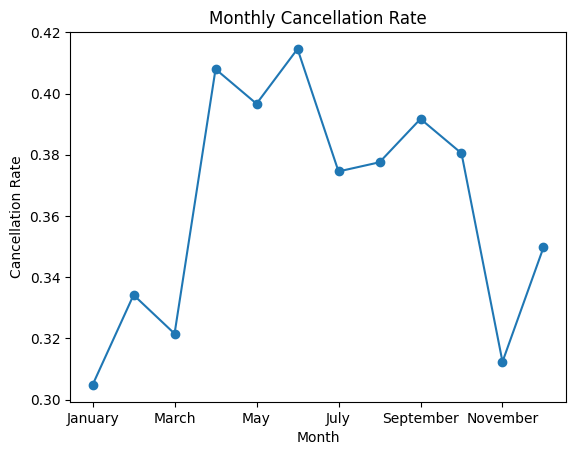

In [47]:
monthly_cancel_rate.plot(kind='line', marker='o', title='Monthly Cancellation Rate')
plt.ylabel('Cancellation Rate')
plt.xlabel('Month')
plt.show()

##### Business Interpretation
- **Cancellation rates change across different months**, showing clear seasonal variation.
- **Peak-season months** often experience **higher cancellation rates**, possibly due to:
  - More **flexible travel plans**
  - **Overbooking behavior** by customers securing multiple options
- Hotels should consider **stricter cancellation policies**, shorter free-cancellation windows, or dynamic pricing during high-demand months.

##### Technical Interpretation
- The **mean of the binary variable `is_canceled`** was used to calculate **monthly cancellation probability**.
- A **line plot** was applied to effectively visualize **seasonal trends and month-to-month variation**.
- This method is well-suited for identifying **patterns over time** in cancellation behavior.


### 3. ADR Trend by Month (Pricing Seasonality)

In [48]:
monthly_adr = (
    df.groupby('arrival_date_month')['adr']
      .median()
      .reindex([
          'January','February','March','April','May','June',
          'July','August','September','October','November','December'
      ])
)

monthly_adr

arrival_date_month
January       71.00
February      75.00
March         79.20
April         96.30
May          108.00
June         115.00
July         118.10
August       130.50
September    100.30
October       85.67
November      73.00
December      75.00
Name: adr, dtype: float64

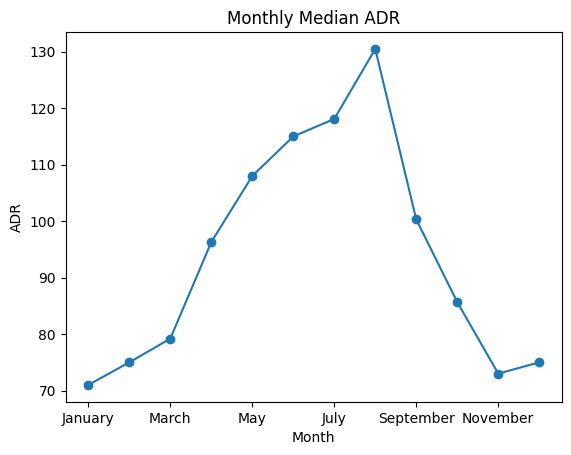

In [49]:

monthly_adr.plot(kind='line', marker='o', title='Monthly Median ADR')
plt.ylabel('ADR')
plt.xlabel('Month')
plt.show()

##### Business Interpretation
- **Average Daily Rate (ADR)** increases during **high-demand months**, reflecting stronger customer willingness to pay.
- Hotels apply **dynamic pricing strategies** based on seasonal demand fluctuations.
- This confirms that the **pricing strategy is well aligned with demand patterns**, helping maximize revenue during peak periods.

##### Technical Interpretation
- **Median ADR** was used instead of the mean to **minimize the impact of outliers** and extreme price values.
- **Trend analysis** across months highlights **cyclical pricing behavior**, clearly showing seasonal effects.
- This approach provides a more **robust and realistic view** of pricing trends over time.


### 4. Year-wise Booking Trend

In [50]:
yearly_bookings = df['arrival_date_year'].value_counts().sort_index()

yearly_bookings

arrival_date_year
2015    21996
2016    56707
2017    40687
Name: count, dtype: int64

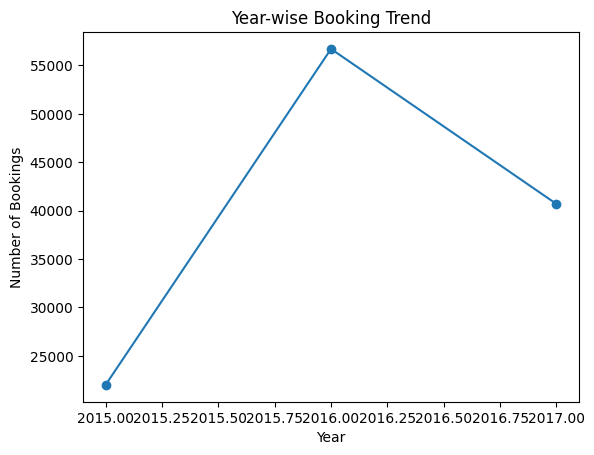

In [51]:
yearly_bookings.plot(kind='line', marker='o', title='Year-wise Booking Trend')
plt.xlabel('Year')
plt.ylabel('Number of Bookings')
plt.show()

##### Business Interpretation
- **Booking volume varies year over year**, indicating changes in overall demand.
- An **upward trend** may suggest **market expansion**, improved brand presence, or successful marketing efforts.
- A **decline** could be influenced by **external factors** such as increased competition, economic conditions, or changes in travel behavior.

##### Technical Interpretation
- **Time-based aggregation** (yearly grouping) was used to analyze long-term booking trends.
- This method helps in identifying **growth patterns, declines, and structural changes** over time.
- The insights are valuable for **demand forecasting**, **capacity planning**, and long-term strategic decisions.


**We analyzed seasonality and time trends to understand demand, pricing, and cancellation behavior across months and years. We also observed clear seasonal patterns in bookings, ADR, and cancellations.**

### STEP 8 – Key Business Insights & Recommendations

#### 1. High Cancellation Rate Is a Major Revenue Risk

- A **significant share of hotel bookings are canceled**, making demand uncertain.
- Frequent cancellations negatively affect **revenue forecasting**, **occupancy planning**, and **room utilization**.
- This highlights the importance of implementing **stronger risk management strategies**, such as improved cancellation policies, overbooking controls, and customer segmentation.


#### 2. Long Lead Time Increases Cancellation Probability

- **Bookings made well in advance** have a higher likelihood of being canceled.
- Customers with **long lead times** often have **uncertain or flexible travel plans**, increasing cancellation risk.

##### Insight
- **Lead time is one of the strongest drivers of cancellation**, making it a critical feature for prediction, segmentation, and policy design.


#### 3. Long Lead Time Increases Cancellation Probability

- **Bookings made well in advance** have a higher likelihood of being canceled.
- Customers with **long lead times** often have **uncertain or flexible travel plans**, increasing cancellation risk.

#####  Insight
- **Lead time is one of the strongest drivers of cancellation**, making it a critical feature for prediction, segmentation, and policy design.


#### 4. Online Travel Agents (OTA): High Volume but High Risk

- **Online Travel Agents (OTAs)** generate the **largest share of bookings**, making them a key distribution channel.
- However, bookings coming through OTAs show **higher cancellation rates** compared to **direct bookings**.

##### Insight
- Heavy dependency on OTAs leads to **higher cancellation risk** as well as **increased commission costs**.
- Encouraging **direct bookings** can improve both **revenue stability** and **profit margins**.


#### 5. Price (ADR) Alone Does Not Drive Cancellation

- The **median ADR** for both **canceled** and **non-canceled** bookings is **very similar**.
- Cancellations are observed **across all price ranges**, not concentrated only in high- or low-priced bookings.

#####  Insight
- **Price alone is not a strong driver of cancellation**.
- Other factors such as **lead time**, **booking channel**, and **customer type** play a more significant role in cancellation behavior.


#### 6. Longer Stay Bookings Are More Reliable

- **Long-stay bookings** have a **lower cancellation rate** compared to short stays.
- The majority of cancellations come from **short-duration bookings**, which are more flexible and easier to cancel.

##### Insight
- Guests planning **longer stays** demonstrate **higher commitment**.
- Stay duration is an important factor for **assessing booking reliability** and can be used for risk-based policies and segmentation.


#### 7.  Clear Seasonality Exists in Demand, Pricing, and Cancellations

- **Booking volume and ADR** rise noticeably during **peak travel months**, indicating strong seasonal demand.
- **Cancellation rates also vary by season**, often increasing during high-demand periods due to flexible travel plans.

##### Insight
- **Seasonal demand requires dynamic pricing, flexible inventory management, and adjusted cancellation policies**.
- Aligning pricing and rules with seasonality helps maximize revenue while controlling cancellation risk.


### Business Recommendations

#### 1. Apply Stricter Policies for Long Lead-Time Bookings

- Introduce **partial prepayments** or **shorter free-cancellation windows** for bookings made far in advance.
- Implement **automated reminder emails** or notifications as the arrival date approaches to reconfirm guest intent and reduce last-minute cancellations.


#### 2. Reduce Dependency on Online Travel Agents

- Promote **direct bookings** to improve reliability and reduce commission costs.
- Encourage guests to book directly through:
  - **Exclusive discounts**
  - **Loyalty and reward programs**
  - **Special offers available only on the hotel website**


#### 3. Promote Long-Stay Incentives

- Offer **discounted rates or bundled deals** for guests booking **extended stays**.
- Actively **target long-stay customers** (business travelers, remote workers, relocations) to ensure **more stable and predictable revenue**.


#### 4. Use Seasonal Pricing & Cancellation Rules

- **Increase ADR** during **high-demand (peak) months** to maximize revenue when demand is strong.
- Apply **stricter cancellation policies** during peak seasons to reduce last-minute cancellations and protect occupancy levels.
- Use **dynamic pricing and policy adjustments** aligned with seasonal demand patterns.


#### 5. Segment Customers Based on Risk

- Identify **high-risk customer segments**, such as bookings with **long lead times made through OTAs**.
- Apply **customized booking and cancellation policies** based on risk level, such as:
  - Higher advance payments
  - Shorter free-cancellation periods
  - Targeted reminders or confirmations

This risk-based segmentation helps **reduce cancellations while maintaining customer satisfaction**.


### Business Recommendations to clients

- Apply stricter cancellation policies for bookings with long lead times.
- Reduce dependency on Online Travel Agents by promoting direct bookings.
- Encourage long-stay bookings through discounts and offers.
- Use dynamic pricing strategies during high-demand seasons.
- Segment customers based on cancellation risk to apply customized policies.


### STEP 9 – Final Conclusion

### Conclusion

- Around **61.07% of guests preferred City Hotels**, while **38.93% preferred Resort Hotels**, indicating higher demand for city-based accommodations.

- City Hotels recorded a **higher number of bookings in 2016 and 2017**. Although Resort Hotels had relatively good bookings in 2016, there was a **noticeable decline in 2017**.

- **City Hotels generated higher Average Daily Rate (ADR)** compared to Resort Hotels, indicating that City Hotels contribute more to overall revenue.

- **91.6% of guests did not require parking spaces**, while only **8.3% required one parking space**, suggesting limited demand for parking facilities.

- **City Hotel bookings experienced longer waiting times**, possibly due to higher demand and limited room availability.

- Overall, **more than 27% of total bookings were canceled**, highlighting a significant revenue risk for the hotel business.

- The months of **July and August recorded the highest number of bookings**, likely due to **summer vacation season** and increased travel activity.

- **Agents with ID 9 and 240 generated the highest number of bookings**, whereas agents with ID 1 and 6 contributed the least.

- The majority of bookings originated from **Portugal, United Kingdom, France, and Spain**, indicating strong demand from these countries.

- Most bookings were made through **Online Travel Agents (OTA)** and **Offline Travel Agents/Tour Operators (TA/TO)**, showing heavy dependency on third-party booking channels.

- **Room types A and D were the most frequently booked** over the last three years, indicating higher guest preference for these room categories.

- Despite having a large customer base, the percentage of **repeated guests is very low**, indicating an opportunity to improve customer retention strategies.

- The **average stay length is approximately 7 days** for both City and Resort Hotels.

- **Bed and Breakfast (BB)** is the most preferred meal option among guests.

- A **negative correlation (-0.51)** exists between `arrival_date_year` and `arrival_date_week_number`, while a **strong positive correlation (0.95)** exists between `stays_in_week_nights` and `total_stay_nights`.

- As the **total number of guests increases, ADR also increases**, indicating a **direct relationship between group size and revenue generation**.

